In [77]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
from skimage.measure import label, regionprops
import math
from collections import deque


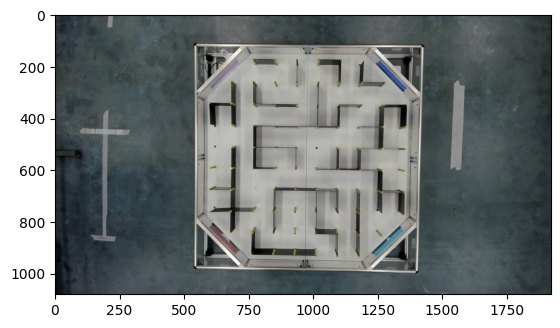

In [78]:
image = cv2.imread("maze_1.jpg")
plt.imshow(image)

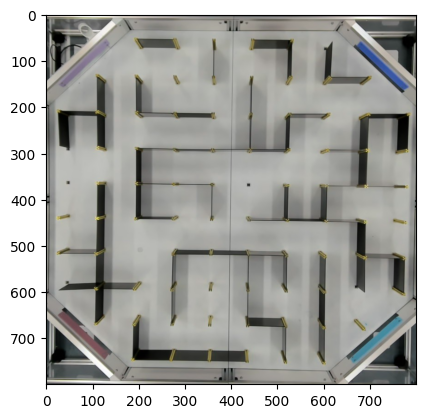

In [79]:
image = cv2.imread("maze_1.jpg")
margin = 30 


src = np.float32([
    [600 - margin, 145 - margin],     # top-left
    [1345 + margin, 145 - margin],    # top-right
    [1345 + margin, 955 + margin],    # bottom-right
    [600 - margin, 955 + margin]      # bottom-left
])

size = 800

dst = np.float32([
    [0, 0],
    [size, 0],
    [size, size],
    [0, size]
])

M = cv2.getPerspectiveTransform(src, dst)

warped = cv2.warpPerspective(
    image,
    M,
    (size, size)
)
plt.imshow(warped)


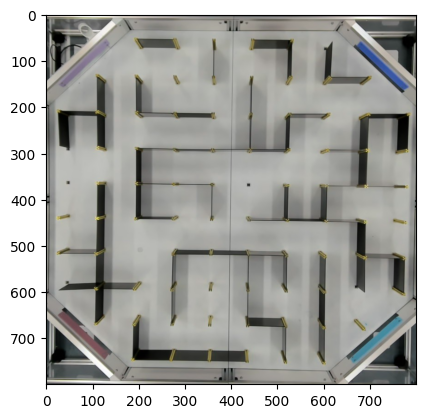

In [80]:
hsv = cv2.cvtColor(warped, cv2.COLOR_BGR2HSV)

H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]
plt.imshow(warped)

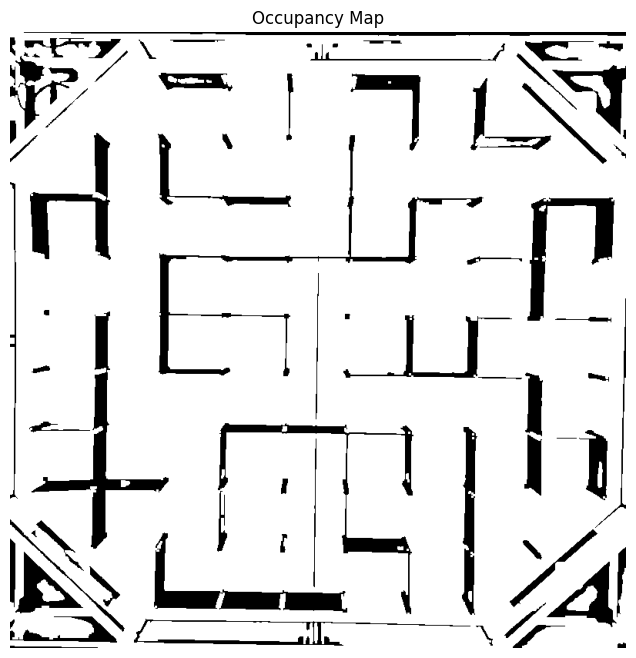

In [81]:
# diff method
gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

# Estimate the slowly-changing background illumination
background = cv2.GaussianBlur(
    gray,
    (51, 51),
    0
)

# Remove large-scale lighting/shadow variation
corrected = cv2.divide(
    gray,
    background,
    scale=255
)

wall_mask = cv2.threshold(
    corrected,
    200,
    255,
    cv2.THRESH_BINARY_INV
)[1]
# 3. Connect broken thin lines using a larger rectangular kernel_2
# Adjust kernel_2 size (e.g., 9x9 or 11x11) based on the size of missing line gaps
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (3, 3)
)

wall_mask = cv2.morphologyEx(
    wall_mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    wall_mask,
    connectivity=8
)

cleaned_walls = np.zeros_like(wall_mask)

MIN_AREA = 20

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area >= MIN_AREA:
        cleaned_walls[labels == i] = 255

# 5. Create final binary map (0 = wall/obstacle, 1 = traversable space for BFS)
# For BFS: 1 is free space, 0 is blocked
occupancy_map_2 = (cleaned_walls == 0).astype(np.uint8)
plt.figure(figsize=(8, 8))
plt.imshow(occupancy_map_2, cmap="gray")
plt.title("Occupancy Map")
plt.axis("off")
plt.show()

this is another approach


In [82]:
wall_mask = ((V < 105) & (S < 110)).astype(np.uint8) * 255
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (5, 5)
)

wall_mask = cv2.morphologyEx(
    wall_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# wall_mask = cv2.morphologyEx(
#     wall_mask,
#     cv2.MORPH_OPEN,
#     kernel
# )


In [83]:
#dilating the walls
# robot_radius_pixels = 10

# kernel = cv2.getStructuringElement(
#     cv2.MORPH_ELLIPSE,
#     (2 * robot_radius_pixels + 1,
#      2 * robot_radius_pixels + 1)
# )

# inflated_map = cv2.dilate(
#     wall_mask,
#     kernel
# )

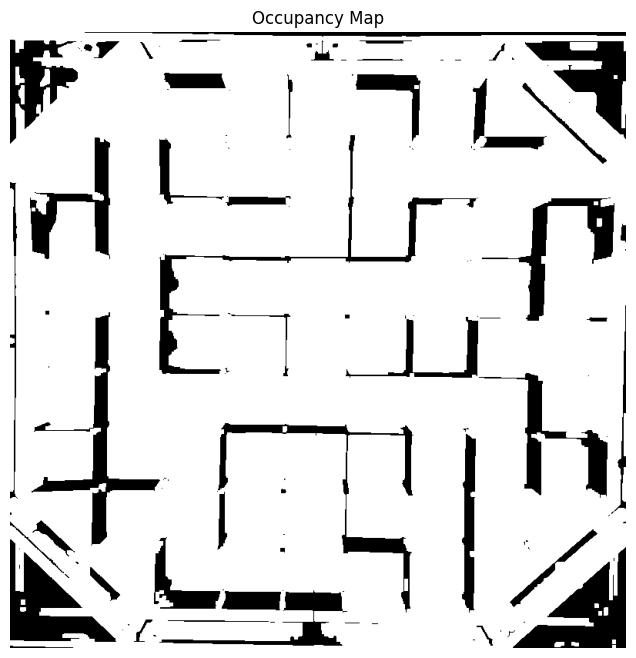

In [84]:
occupancy_map = (wall_mask > 0).astype(np.uint8)
import matplotlib.pyplot as plt
final_map = 255 - occupancy_map
plt.figure(figsize=(8, 8))
plt.imshow(final_map, cmap="gray")
plt.title("Occupancy Map")
plt.axis("off")
plt.show()

This method below connects incomplete lines or at least brings them closer


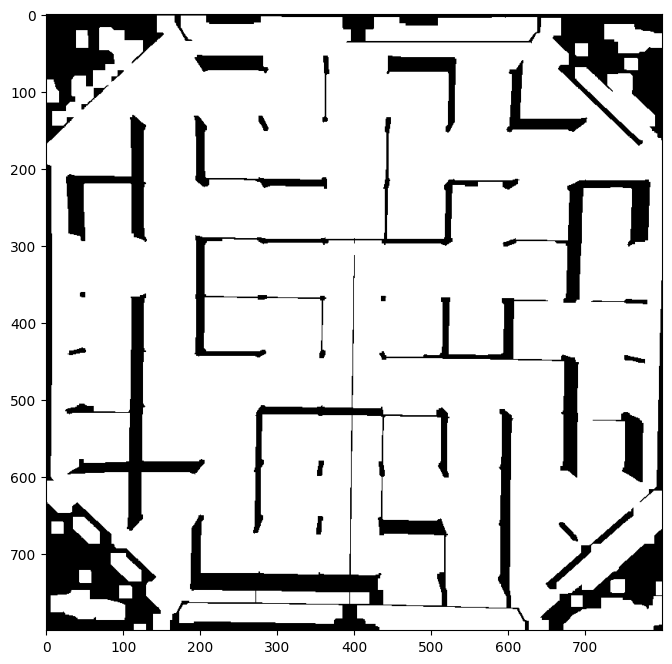

In [85]:
#trying to connect broken lines

kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (15, 15)
)

connected_mask = cv2.morphologyEx(
    cleaned_walls,
    cv2.MORPH_CLOSE,
    kernel
)
labels = label(
    connected_mask,
    connectivity=1
)
clean_mask = np.zeros_like(cleaned_walls)

for region in regionprops(labels):

    if region.area >= 20:
        clean_mask[labels == region.label] = 255
final_map_2 = 255- clean_mask

plt.figure(figsize=(8, 8))
plt.imshow(final_map_2, cmap="gray")

## Starting maaking it into a graph

In [86]:
class Node:
    def __init__(self, node_id, x, y,parent = None):
        self.id = node_id
        self.x = x
        self.y = y
        self.parent = parent
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        self.nodes[node_id] = Node(node_id,x,y)
        self.edges[node_id] = []

    
    def add_edge(self, node_id1, node_id2, weight=0):
        self.edges[node_id1].append((node_id2,weight))

    def remove_edge(self, node_id1, node_id2):
        for edge in self.edges[node_id1]:
            if edge[0] == node_id2:
                self.edges[node_id1].remove(edge)
            break
    
    
    def get_nodes(self):
        pass
    
    def get_edge_weight(self, node_id1, node_id2):
        for edge in self.edges[node_id1]:
            if edge[0] == node_id2:
                return edge[1]

In [87]:
#constants

GRID_N = 9
# some helpers
def get_node_id(row,col,grid = GRID_N):
    return row * grid + col
def get_coordinates(node_id, grid_n=GRID_N):
    return node_id // grid_n, node_id % grid_n

def cell_center(row, col, img_shape, grid_n=GRID_N):
    h, w = img_shape[:2]
    cell_h, cell_w = h / grid_n, w / grid_n
    x = int((col + 0.5) * cell_w)
    y = int((row + 0.5) * cell_h)
    return x, y
def generate_nodes(occupancy_map, grid_n = GRID_N):
    h,w = occupancy_map.shape
    cell_h, cell_w = h / grid_n , w / grid_n
    node_positions = {}
    for row in range(grid_n):
        for col in range(grid_n):
            x = round((col + 0.5) * cell_w)
            y = round((row + 0.5) * cell_h)
            node_positions[get_node_id(row, col , grid_n)] = (x,y)
    return node_positions

In [88]:
def path_clear(x1, y1, x2, y2, occupancy_map ):
  
    distance =int( math.dist((x1,y1),(x2,y2)))
    for i in range(distance + 1):
        t = i / distance if distance > 0 else 0
        x = round(x1 + t * (x2 - x1))
        y = round(y1 + t * (y2 - y1))
        if not isfree(image[y, x]):
            return False
    return True

In [89]:
def  isfree(pixel):
    return (pixel[0] > 200 and pixel[1] > 200 and pixel[2] > 200)

In [90]:
def add_edges(bfs_graph, node_positions,occupancy_map , grid_n = GRID_N):
    for node_id, (x, y) in node_positions.items():

        row = node_id // grid_n
        col = node_id % grid_n

        if col < grid_n - 1:
            right = node_id + 1
            x2, y2 = node_positions[right]

            if path_clear( x, y, x2, y2, occupancy_map):
                bfs_graph.add_edge(node_id, right, 1)
                bfs_graph.add_edge(right, node_id, 1)

        
        if row < grid_n - 1:
            down = node_id + grid_n
            x2, y2 = node_positions[down]

            if path_clear( x, y, x2, y2,occupancy_map):
                bfs_graph.add_edge(node_id, down, 1)
                bfs_graph.add_edge(down, node_id, 1)

In [91]:
def create_graph(occupancy_map, grid_n = GRID_N):
    node_positions = generate_nodes(occupancy_map, grid_n)
    bfs_graph = Graph()
    for node_id , (x,y) in node_positions.items():
        bfs_graph.add_node(node_id, x, y)
    add_edges(bfs_graph , node_positions, occupancy_map, grid_n)
    return bfs_graph
    

In [92]:
def bfs_shortest_path(graph, start_id, goal_id):
    if start_id == goal_id:
        return [start_id]

    visited = {start_id}
    parent = {}
    queue = deque([start_id])

    while queue:
        current = queue.popleft()
        for neighbour_id, _weight in graph.edges[current]:
            if neighbour_id not in visited:
                visited.add(neighbour_id)
                parent[neighbour_id] = current
                if neighbour_id == goal_id:
                    path = [goal_id]
                    while path[-1] != start_id:
                        path.append(parent[path[-1]])
                    path.reverse()
                    return path
                queue.append(neighbour_id)

    return None  


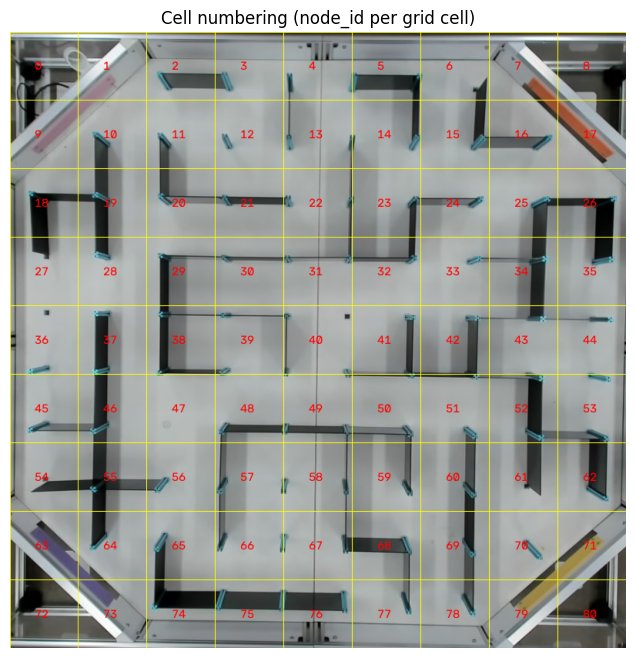

In [96]:
def show_cell_numbers(base_img, occupancy_map, grid_n=GRID_N):
    node_positions = generate_nodes(occupancy_map, grid_n)  # same positions used to build the graph
    vis = base_img.copy()
    h, w = vis.shape[:2]
    cell_h, cell_w = h / grid_n, w / grid_n

    # grid lines
    for i in range(grid_n + 1):
        y, x = int(i * cell_h), int(i * cell_w)
        cv2.line(vis, (0, y), (w, y), (0, 255, 255), 1)
        cv2.line(vis, (x, 0), (x, h), (0, 255, 255), 1)

    # node id label at each cell centre
    for node_id, (x, y) in node_positions.items():
        cv2.putText(vis, str(node_id), (x - 12, y + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Cell numbering (node_id per grid cell)")
    plt.axis("off")
    plt.show()

show_cell_numbers(warped, occupancy_source, GRID_N)

In [93]:
def draw_path_on_image(base_img, cells, grid_n=GRID_N):
    vis = base_img.copy()
    h, w = vis.shape[:2]
    cell_h, cell_w = h / grid_n, w / grid_n

    for i in range(grid_n + 1):
        y, x = int(i * cell_h), int(i * cell_w)
        cv2.line(vis, (0, y), (w, y), (0, 255, 255), 1)
        cv2.line(vis, (x, 0), (x, h), (0, 255, 255), 1)

    pts = [(int((c + 0.5) * cell_w), int((r + 0.5) * cell_h)) for r, c in cells]
    for p1, p2 in zip(pts, pts[1:]):
        cv2.line(vis, p1, p2, (255, 0, 0), 3)
    for p in pts:
        cv2.circle(vis, p, 6, (0, 0, 255), -1)
    cv2.circle(vis, pts[0], 10, (0, 255, 0), -1)   # start = green
    cv2.circle(vis, pts[-1], 10, (0, 0, 255), -1)  # goal = red

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Grid + Solved Path")
    plt.axis("off")
    plt.show()


In [95]:
START = (1, 6, "N")
GOAL = (5, 2)

occupancy_source = occupancy_map_2  # swap for `occupancy_map` or the final_map_2-derived mask if you trust one of those more

graph = create_graph(occupancy_source, grid_n=GRID_N)

start_id = get_node_id(START[0], START[1], GRID_N)
goal_id = get_node_id(GOAL[0], GOAL[1], GRID_N)

node_path = bfs_shortest_path(graph, start_id, goal_id)

if node_path is None:
    print("No path found - check the occupancy map / wall detection before re-running.")
else:
    commands, cells = path_to_commands(node_path, START[2], GRID_N)
    command_string = "".join(commands)

    print("Grid cells visited:", cells)
    print("Command string:", command_string)

    draw_path_on_image(warped, cells, GRID_N)

No path found - check the occupancy map / wall detection before re-running.
